In [1]:
import argparse
import logging
from concurrent.futures import ThreadPoolExecutor, as_completed
from concurrent.futures.process import BrokenProcessPool
from functools import partial
from pathlib import Path

import pandas as pd
import rdkit
from posebusters import PoseBusters
from rdkit import Chem
from rdkit.Chem.AllChem import GetMolFrags
from rdkit.Chem.Draw import MolsToGridImage
from rdkit.Chem.MolStandardize.rdMolStandardize import CleanupParameters, LargestFragmentChooser
from rdkit.Chem.rdchem import Mol
from rdkit.Chem.rdDistGeom import EmbedMultipleConfs
from rdkit.Chem.rdForceFieldHelpers import MMFFOptimizeMolecule
from rdkit.Chem.rdmolfiles import MolFromMolBlock, MolFromMolFile, MolToMolBlock
from rdkit.Chem.rdmolops import AddHs, SanitizeMol
from rdkit.rdBase import LogToPythonLogger
from rich.logging import RichHandler
from rich.progress import BarColumn, MofNCompleteColumn, Progress, TaskProgressColumn, TextColumn, TimeRemainingColumn, track
from tqdm import tqdm

In [2]:
level = logging.CRITICAL
logging.basicConfig(level=level, format="%(message)s", datefmt="[%X]", handlers=[RichHandler(markup=True, rich_tracebacks=True)])

logger = logging.getLogger("rdkit")
logger.setLevel(level)
logger.addHandler(RichHandler(rich_tracebacks=True))
logger.removeHandler(logger.handlers[0])
LogToPythonLogger()

In [3]:
from tools import count_radicals

In [4]:
file_conf = "/vols/opig/users/buttensc/Storage/Projects/3d_mol_gen_benchmark/data/01_raw/geoldm_100000_predictions.sdf"
file_eval = "/vols/opig/users/buttensc/Storage/Projects/3d_mol_gen_benchmark/data/03_evaluation/geoldm_100000_predictions.csv"

In [5]:
# # check successes
# df = pd.read_csv(file_eval, low_memory=False)
# df["i"] = df["name"].str.split("_").str[-1].astype(pd.Int64Dtype())
# available = set(df["i"].values)
# missing = set(range(100000)) - available

In [6]:
# load missing
with open(file_conf) as f:
    blocks = f.read().strip().strip("$$$$").split("$$$$\n")
# blocks = {i: b for i, b in enumerate(blocks) if i in m}

In [7]:
i = 46293

print(i)
mol = MolFromMolBlock(blocks[i])
mol.RemoveAllConformers()
EmbedMultipleConfs(AddHs(mol), numConfs=1, randomSeed=42)
print("success")

46293
success


In [8]:
import argparse
import logging
from concurrent.futures import ThreadPoolExecutor, as_completed
from concurrent.futures.process import BrokenProcessPool
from functools import partial
from pathlib import Path

import pandas as pd
import rdkit
from posebusters import PoseBusters
from rdkit import Chem
from rdkit.Chem.AllChem import GetMolFrags
from rdkit.Chem.Draw import MolsToGridImage
from rdkit.Chem.MolStandardize.rdMolStandardize import CleanupParameters, LargestFragmentChooser
from rdkit.Chem.rdchem import BondStereo, Mol
from rdkit.Chem.rdDistGeom import EmbedMultipleConfs
from rdkit.Chem.rdForceFieldHelpers import MMFFOptimizeMolecule
from rdkit.Chem.rdmolfiles import MolFromMolBlock, MolFromMolFile, MolToMolBlock
from rdkit.Chem.rdmolops import AddHs, SanitizeMol
from rdkit.rdBase import LogToPythonLogger
from rich.logging import RichHandler
from rich.progress import BarColumn, MofNCompleteColumn, Progress, TaskProgressColumn, TextColumn, TimeRemainingColumn, track
from tqdm import tqdm

In [9]:
file_conf = "/vols/opig/users/buttensc/Storage/Projects/3d_mol_gen_benchmark/data/01_raw/geoldm_100000_predictions.sdf"
file_eval = "/vols/opig/users/buttensc/Storage/Projects/3d_mol_gen_benchmark/data/03_evaluation/geoldm_100000_predictions.csv"

In [10]:
# load missing
with open(file_conf) as f:
    blocks = f.read().strip().strip("$$$$").split("$$$$\n")
# blocks = {i: b for i, b in enumerate(blocks) if i in m}

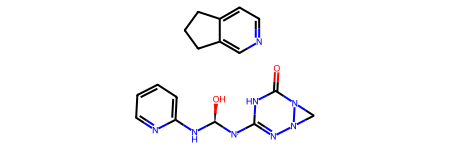

In [11]:
i = 46293

mol = MolFromMolBlock(blocks[i])
mol.RemoveAllConformers()
mol

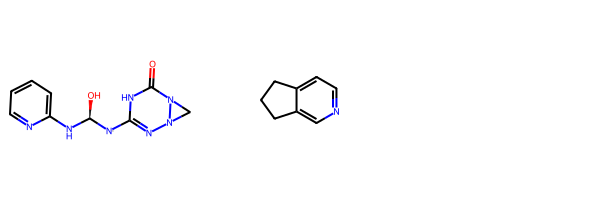

In [12]:
mols = GetMolFrags(mol, asMols=True)
MolsToGridImage(mols)

In [13]:
i = 29493  # analyzed_molecules_2/molecule_953.txt
# i = 46337
print(i)
block = blocks[i]
block
# mol = MolFromMolBlock(block)
# mol

29493


'analyzed_molecules_2/molecule_953.txt\n OpenBabel02102514313D\n\nemptied_to_avoid_segmentation_fault\n'

In [14]:
# EmbedMultipleConfs(AddHs(mol), numConfs=1, randomSeed=42)

In [15]:
# get stereo bonds
mol = MolFromMolBlock(block)
bonds = mol.GetBonds()

AttributeError: 'NoneType' object has no attribute 'GetBonds'

In [ ]:
for bond in bonds:
    # print stereo
    if bond.GetStereo() == BondStereo.STEREOANY:
        if len(bond.GetStereoAtoms()) < 2:
            bond.SetStereo(BondStereo.STEREONONE)
mol = EmbedMultipleConfs(AddHs(mol), numConfs=1, randomSeed=42)